<a href="https://colab.research.google.com/github/apesnajnin1/Python_Data-Analytics_PGD/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#i. Generate a DataFrame by reading the provided dataset
#Read the file and show all the rows

from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('WHO_Suicide_Case.csv')
print(df)

Saving WHO_Suicide_Case.csv to WHO_Suicide_Case.csv
     Region Name Country Name  Year     Sex  0 Year  1-4 Years  5-9 Years  \
0         Africa   Cabo Verde  1980  Female     0.0        0.0        0.0   
1         Africa   Cabo Verde  1980    Male     0.0        0.0        0.0   
2         Africa   Cabo Verde  2011  Female     0.0        0.0        0.0   
3         Africa   Cabo Verde  2011    Male     0.0        0.0        0.0   
4         Africa        Egypt  1965  Female     0.0        0.0        0.0   
...          ...          ...   ...     ...     ...        ...        ...   
9533     Oceania  New Zealand  2014    Male     0.0        0.0        0.0   
9534     Oceania  New Zealand  2015  Female     0.0        0.0        0.0   
9535     Oceania  New Zealand  2015    Male     0.0        0.0        0.0   
9536     Oceania  New Zealand  2016  Female     0.0        0.0        0.0   
9537     Oceania  New Zealand  2016    Male     0.0        0.0        0.0   

      10-14 Years  15-1

In [2]:
#ii. Print the Column Names of the dataset
print(df.columns)

Index(['Region Name', 'Country Name', 'Year', 'Sex', '0 Year', '1-4 Years',
       '5-9 Years', '10-14 Years', '15-19 Years', '20-24 Years', '25-29 Years',
       '30-34 Years', '35-39 Years', '40-44 Years', '45-49 Years',
       '50-54 Years', '55-59 Years', '60-64 Years', '65-69 Years',
       '70-74 Years', '75-79 Years', '80-84 Years', '85+ Years', 'Unknown Age',
       'No of Suicides',
       'Percentage of cause-specific deaths out of total deaths',
       'Death rate per 100 000 population'],
      dtype='object')


In [3]:
#Detecting missing data
print(df.isnull().sum())

Region Name                                                0
Country Name                                               0
Year                                                       0
Sex                                                        0
0 Year                                                     0
1-4 Years                                                  0
5-9 Years                                                  0
10-14 Years                                                0
15-19 Years                                                0
20-24 Years                                                0
25-29 Years                                                0
30-34 Years                                                0
35-39 Years                                                0
40-44 Years                                                0
45-49 Years                                                0
50-54 Years                                                0
55-59 Years             

In [4]:
# show any redundant row
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9533,False
9534,False
9535,False
9536,False


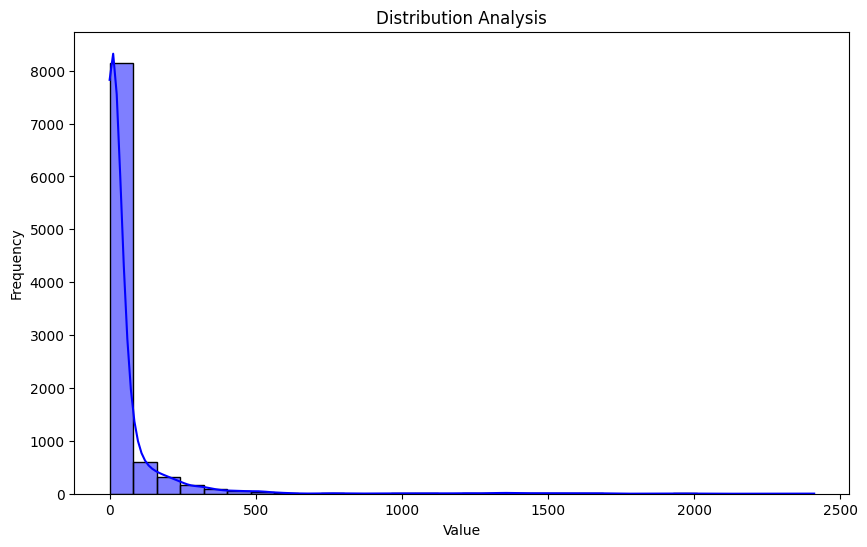

Skewness: 7.33789608300367


In [5]:
#Whether data skewed or normally distributed
import seaborn as sns
import matplotlib.pyplot as plt
#1. Select any column
data = df['15-19 Years']

# 2. Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(data, kde=True, color='blue', bins=30)
plt.title('Distribution Analysis')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# 3. Calculate skewness value
skewness = data.skew()
print(f"Skewness: {skewness}")
# Interpretation: < -1 or > 1: highly skewed
# -1 to -0.5 or 0.5 to 1: moderately skewed [5, 7]

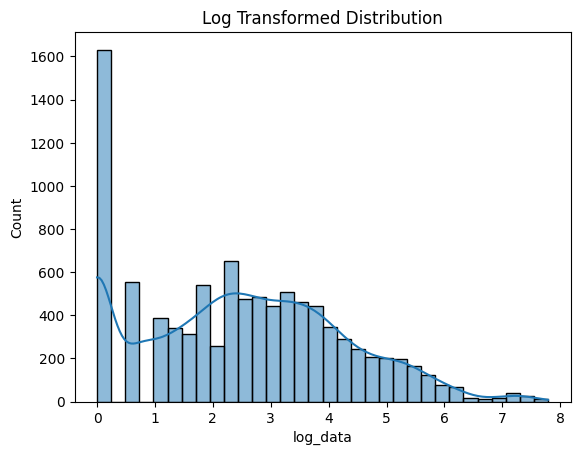

In [6]:
# Apply log transformation for right-skewed data
import numpy as np
df['log_data'] = np.log1p(df['15-19 Years']) # log1p handles zero values
sns.histplot(df['log_data'], kde=True)
plt.title('Log Transformed Distribution')
plt.show()

In [8]:
import pandas as pd
column_name = '15-19 Years'
# Calculate Q1, Q3 and IQR
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
# This keeps only the rows that are WITHIN the bounds
df_cleaned = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")

Original rows: 9538
Cleaned rows: 8339


In [9]:
#Feature Engineering
# Show unique values from a specific column
Country_Names = sorted(df['Country Name'].unique())

print(Country_Names)

['Albania', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bosnia and Herzegovina', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Cabo Verde', 'Canada', 'Chile', 'China, Hong Kong SAR', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Finland', 'France', 'French Guiana', 'Georgia', 'Germany', 'Greece', 'Grenada', 'Guadeloupe', 'Guatemala', 'Guyana', 'Hungary', 'Iceland', 'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Maldives', 'Malta', 'Martinique', 'Mauritius', 'Mayotte', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'New Zealand', 'Nicaragua', 'North Macedonia', 'Norway', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Phil

In [10]:
import csv

unique_values = set()

with open('WHO_Suicide_Case.csv', mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        unique_values.add(row['Country Name'])

print(unique_values)

{'Kyrgyzstan', 'Republic of Moldova', 'Dominican Republic', 'Guatemala', 'United Kingdom of Great Britain and Northern Ireland', 'Maldives', 'Trinidad and Tobago', 'Slovenia', 'Turkmenistan', 'Fiji', 'Barbados', 'Armenia', 'Latvia', 'Puerto Rico', 'Belarus', 'Netherlands', 'Australia', 'Dominica', 'Montenegro', 'R?union', 'Switzerland', 'Sri Lanka', 'Romania', 'Peru', 'Egypt', 'Cyprus', 'Poland', 'Saint Vincent and the Grenadines', 'Brazil', 'Jamaica', 'Qatar', 'Malta', 'Venezuela (Bolivarian Republic of)', 'Saint Kitts and Nevis', 'Spain', 'Cuba', 'Mexico', 'Georgia', 'United Arab Emirates', 'Kazakhstan', 'Luxembourg', 'United States of America', 'Jordan', 'China, Hong Kong SAR', 'Uruguay', 'Croatia', 'Martinique', 'Iran (Islamic Republic of)', 'Argentina', 'Iceland', 'Guadeloupe', 'Colombia', 'Mayotte', 'Grenada', 'Estonia', 'Mongolia', 'Italy', 'T?rkiye', 'Paraguay', 'Japan', 'Ireland', 'Sao Tome and Principe', 'Sweden', 'Saint Lucia', 'Chile', 'El Salvador', 'Bahamas', 'Lithuania',

In [11]:
#Feature Engineering - Sex-wise datafile creation
for sex, group in df.groupby('Sex'):
    group.to_csv(f'data_{sex}.csv')
    print(f"Created: data_{sex}.csv")


Created: data_Female.csv
Created: data_Male.csv
Created: data_Unknown.csv


In [12]:
no_of_death = df['Sex'].value_counts()
print(no_of_death, '\n\n\n')

#cross check the death value in newly created data file
df_female = pd.read_csv('data_Female.csv')
#print(df_female)
no_of_death_female = df_female['Sex'].value_counts()
print(no_of_death_female, '\n\n\n')

df_male = pd.read_csv('data_Male.csv')
#print(df_male)
no_of_death_male = df_male['Sex'].value_counts()
print(no_of_death_male, '\n\n\n')

df_unknown = pd.read_csv('data_Unknown.csv')
#print(df_unknown)
no_of_death_unknown = df_unknown['Sex'].value_counts()
print(no_of_death_unknown, '\n\n\n')



Sex
Female     4721
Male       4721
Unknown      96
Name: count, dtype: int64 



Sex
Female    4721
Name: count, dtype: int64 



Sex
Male    4721
Name: count, dtype: int64 



Sex
Unknown    96
Name: count, dtype: int64 





In [13]:
print(df_female)


      Unnamed: 0 Region Name Country Name  Year     Sex  0 Year  1-4 Years  \
0              0      Africa   Cabo Verde  1980  Female     0.0        0.0   
1              2      Africa   Cabo Verde  2011  Female     0.0        0.0   
2              4      Africa        Egypt  1965  Female     0.0        0.0   
3              6      Africa        Egypt  1973  Female     0.0        0.0   
4              8      Africa        Egypt  1974  Female     0.0        0.0   
...          ...         ...          ...   ...     ...     ...        ...   
4716        9528     Oceania  New Zealand  2012  Female     0.0        0.0   
4717        9530     Oceania  New Zealand  2013  Female     0.0        0.0   
4718        9532     Oceania  New Zealand  2014  Female     0.0        0.0   
4719        9534     Oceania  New Zealand  2015  Female     0.0        0.0   
4720        9536     Oceania  New Zealand  2016  Female     0.0        0.0   

      5-9 Years  10-14 Years  15-19 Years  ...  65-69 Years  70

In [15]:
#Show data for certain country in data_Female.csv
females_death_by_country = df_female[df_female['Country Name'] == 'Egypt']
print(females_death_by_country, '\n\n\n')

#females_death_by_country_1 = df_female[df_female['Country Name'] == 'United States of America']
#print(females_death_by_country_1, '\n\n\n')



    Unnamed: 0 Region Name Country Name  Year     Sex  0 Year  1-4 Years  \
2            4      Africa        Egypt  1965  Female     0.0        0.0   
3            6      Africa        Egypt  1973  Female     0.0        0.0   
4            8      Africa        Egypt  1974  Female     0.0        0.0   
5           10      Africa        Egypt  1975  Female     0.0        0.0   
6           12      Africa        Egypt  1976  Female     0.0        0.0   
7           14      Africa        Egypt  1977  Female     0.0        0.0   
8           16      Africa        Egypt  1978  Female     0.0        0.0   
9           18      Africa        Egypt  1979  Female     0.0        0.0   
10          20      Africa        Egypt  1980  Female     0.0        0.0   
11          22      Africa        Egypt  1987  Female     0.0        0.0   
12          24      Africa        Egypt  2000  Female     0.0        1.0   
13          26      Africa        Egypt  2001  Female     0.0        0.0   
14          

In [16]:
# Aggregate 'No of Suicides' by Age group for female data
#target_country = 'Egypt'
#target_country = 'United States of America'
#target_country = 'Venezuela (Bolivarian Republic of)'
target_country ='Israel'


# List of all age group columns you want to sum
age_groups = ['0 Year', '1-4 Years', '5-9 Years', '10-14 Years', '15-19 Years', '20-24 Years',
              '25-29 Years', '30-34 Years', '35-39 Years', '40-44 Years', '45-49 Years', '50-54 Years',
              '55-59 Years', '60-64 Years', '65-69 Years', '70-74 Years', '75-79 Years', '80-84 Years',
              '85+ Years', 'Unknown Age']

# Loop through each age group
for group in age_groups:
    # Filter and sum for the current group in the loop
    total_deaths = df_female[df_female['Country Name'] == target_country][group].sum()

    print(f"Total deaths in {target_country} for years ({group}): {total_deaths}")

Total deaths in Israel for years (0 Year): 0.0
Total deaths in Israel for years (1-4 Years): 0.0
Total deaths in Israel for years (5-9 Years): 1.0
Total deaths in Israel for years (10-14 Years): 34.0
Total deaths in Israel for years (15-19 Years): 189.0
Total deaths in Israel for years (20-24 Years): 297.0
Total deaths in Israel for years (25-29 Years): 286.0
Total deaths in Israel for years (30-34 Years): 312.0
Total deaths in Israel for years (35-39 Years): 266.0
Total deaths in Israel for years (40-44 Years): 266.0
Total deaths in Israel for years (45-49 Years): 268.0
Total deaths in Israel for years (50-54 Years): 286.0
Total deaths in Israel for years (55-59 Years): 316.0
Total deaths in Israel for years (60-64 Years): 261.0
Total deaths in Israel for years (65-69 Years): 306.0
Total deaths in Israel for years (70-74 Years): 278.0
Total deaths in Israel for years (75-79 Years): 239.0
Total deaths in Israel for years (80-84 Years): 200.0
Total deaths in Israel for years (85+ Years)

In [17]:
#Find the maximum no. of suicide in which Age Group
# 1. Store results in a dictionary
results = {}
for group in age_groups:
    total = df_female[df_female['Country Name'] == target_country][group].sum()
    results[group] = total

# 2. Find the group with the maximum value
max_group = max(results, key=results.get)
max_value = results[max_group]

print(f"The highest number of deaths is {max_value} in the '{max_group}' category.")

# 3. Find the group with the minimum value
min_group = min(results, key=results.get)
min_value = results[min_group]

print(f"The lowest number of deaths is {min_value} in the '{min_group}' category.")

The highest number of deaths is 316.0 in the '55-59 Years' category.
The lowest number of deaths is 0.0 in the '0 Year' category.


In [18]:
# 1. This gives a sum for every country individually
country_totals = df_female.groupby('Country Name')[age_groups].sum()

print("\nTotal deaths by country:")
print(country_totals, '\n\n\n')

# 2.Identify the country with the maximum total suicides
max_country = country_totals.idxmax()
max_total = country_totals.max()

print(f"The country with the maximum total suicides is {max_country} with {max_total,'\n\n\n'} deaths.")

# 3. Find the specific age group that has the highest number globally
age_group_totals = df_female[age_groups].sum()
top_age_group = age_group_totals.idxmax()
print(f"The age group with the highest number of deaths globally is {top_age_group}.")


Total deaths by country:
                                                    0 Year  1-4 Years  \
Country Name                                                            
Albania                                                0.0        0.0   
Antigua and Barbuda                                    0.0        0.0   
Argentina                                              0.0        0.0   
Armenia                                                0.0        0.0   
Australia                                              0.0        0.0   
...                                                    ...        ...   
United Kingdom of Great Britain and Northern Ir...     0.0        0.0   
United States of America                               0.0        0.0   
Uruguay                                                0.0        0.0   
Uzbekistan                                             0.0        0.0   
Venezuela (Bolivarian Republic of)                     0.0        0.0   

                        

In [20]:
# 2. Sum deaths for all age groups across each country
# This creates a total suicide count per country
#country_sums = df_female.groupby('Country Name')[age_groups].sum()
#print(country_sums)

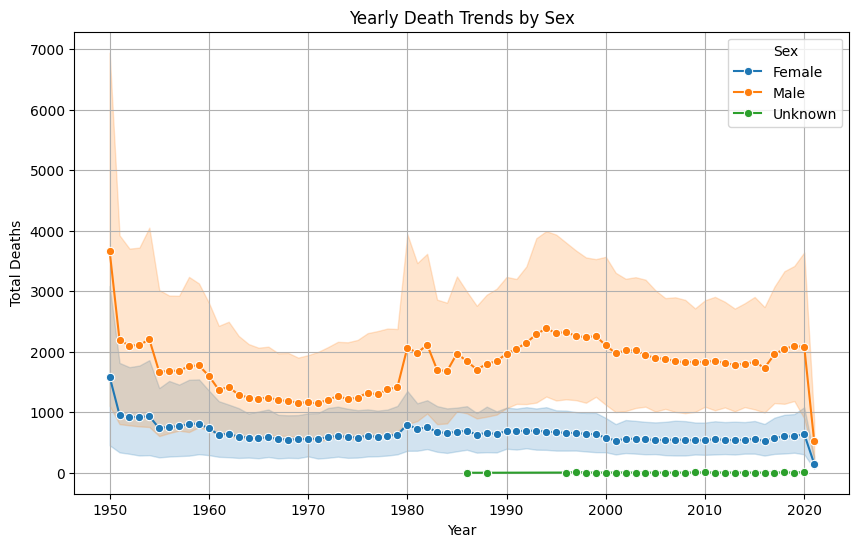

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sum all age groups to get a 'Total' column first
age_groups = ['0 Year', '1-4 Years', '5-9 Years', '10-14 Years', '15-19 Years', '20-24 Years',
              '25-29 Years', '30-34 Years', '35-39 Years', '40-44 Years', '45-49 Years', '50-54 Years',
              '55-59 Years', '60-64 Years', '65-69 Years', '70-74 Years', '75-79 Years', '80-84 Years',
              '85+ Years', 'Unknown Age']

df['Total Deaths'] = df[age_groups].sum(axis=1)

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Total Deaths', hue='Sex', marker='o')

plt.title('Yearly Death Trends by Sex')
plt.ylabel('Total Deaths')
plt.xlabel('Year')
plt.grid(True)
plt.show()